# Lab 1: The Apollo Missions

## Introduction
------

Imagine you are an engineer working on the very early days of the Apollo program. In order to
send people to the moon, you need a basic understanding of the gravitational potential and forces
the mission will experience. You also need to start quantifying the performance of the new rocket
that will carry the capsule: the Saturn V.

Your team at NASA has been tasked with conducting a series of investigations, which you are guided through below.
You will make some plots, and also write some short paragraphs with your scientific conclusions.
The NASA Director Gene Kranz will use your notebook to defend NASA funding to congress.
So your answers should be short and to the point, quantitative in nature, 
and contain highly polished plots, with appropriate titles, units, etc.

**Other important requirements:**
- Your final notebook---BOTH the .ipynb file AND the html export---should be COMMITTED and PUSHED to your fork of the PHYS265-spring26 GitHub repository. Instructions for doing this are available [online]( https://github.com/astroumd/PHYS265-spring26/blob/main/github.pdf).
- All plotting should be done in object oriented fashion, as discussed in class. 
Any use of “`plt.plot()`” will result in zero points being awarded for that question.
- Before submitting your work, reset JLD and then re-run your final code (Kernel → Restart Kernel and Run All Cells…) Make sure your code executes as intended and without error. The first cell should be "1", and the cells should execute in order.

A table of relevant physical constants is below. Good luck!

| Quantity | Value |
|----------|-------|
| Gravitational Constant ($G$) | $6.67 \times 10^{-11}$ m³/kg/s² |
| Gravitational Acceleration ($g$) | 9.81 m/s² |
| Mass of the Earth ($M_E$) | $5.9 \times 10^{24}$ kg |
| Mass of the Moon ($M_M$) | $7.3 \times 10^{22}$ kg |
| Mass of Apollo Command Module | 5500 kg |
| Radius of the Earth ($R_E$) | 6378 km |
| Radius of the Moon ($R_M$) | 1737 km |
| Distance from Earth to Moon ($d_{EM}$) | $3.8 \times 10^{8}$ m |
| Exhaust Velocity of Saturn V Stage 1 (S-1C) ($v_e$) | $2.4 \times 10^{3}$ m/s |
| Burn Rate of S-1C ($\dot{m}$) | $1.3 \times 10^{4}$ kg/s |
| Wet Mass of S-1C ($m_0$) | $2.8 \times 10^{6}$ kg |
| Dry Mass of S-1C ($m_f$) | $7.5 \times 10^5$ kg |

In [1]:
#show
# In the code cell beneath this one you can put your imports,
# and define any variables you might need (e.g. the mass of the earth)

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import math
from scipy.integrate import quad
G = 6.67e-11
M_earth = 5.9e24
M_moon = 7.3e22
R_earth = 6.378e6
d_to_moon = 3.8e8
apollo_command_mass = 5.5e3
mdot = 1.3e4
m0 = 2.8e6
mf = 7.5e5
ve = 2.4e3
g = 9.81

## Part 1: The Gravitational Potential of the Earth
----

The gravitational potential at a distance $r$ from a mass $M$ is given by:

$$\Phi(r) = -\frac{GM}{r}$$

where G is the gravitational constant.

1. Code up a function that takes as an input the mass of a body $M$ , the cartesian location of the
mass $(x_M , y_M)$, and the location of some distant evaluation point $(x, y)$. Have the function
return the potential at the evaluation point. You may consider approximating the Earth as
a point particle, but in which case, be careful! For in that approximation, the the potential
contains a singularity. In our function, use all modern best practices for coding.
E.g. type hints, type checks, pre and post conditions, doc strings, etc.

In [3]:
def V(M, x_M, y_M, x, y):
    """ Calculates the gravitational potential due to the mass M at x_M, y_M at position x,y.
        Approximates M as a point mass.
        Inputs: >0 float M, float x_M, float y_M, float x, float y
        Returns: np.float64 -G*M/r, distance r
    """
    precond = (float, int, np.floating, np.ndarray)
    if not (isinstance(M, precond) and isinstance(x_M,precond) and isinstance(y_M,precond) and isinstance(x,precond) and isinstance(y,precond)):
        raise TypeError
    if M<0:
        raise ValueError
    r = np.sqrt((x_M-x)**2+(y_M-y)**2)
    if np.linalg.norm(r)==0:
        return np.nan
        print("Potential diverged.")
    if not (type(-G*M/r)==np.ndarray or type(-G*M/r)==float):
        print("Warning: Potential is not a float.")
        print(type(-G*M/r))
    return -G*M/r

2. Make a 1D plot of the absolute value of the gravitational potential $|\Phi|$ as a function of distance $x$ from the surface of the Earth, assuming $y = 0$.
Plot out to $1.5\times$ the distance from the Earth to the Moon. Because the potential falls quickly with r, make the y-axis logarithmic to visualize it better.

<class 'function'>


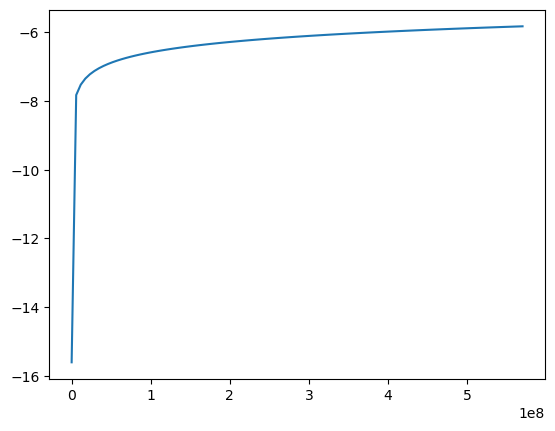

In [4]:
x = np.linspace(0.1, 1.5*d_to_moon, 100)
potential = V(M_earth, 0.0, 0.0, x, 0.0) 
print(type(V))
fig, ax = plt.subplots()
ax.plot(x,-np.log10(-potential))
plt.show()


3. Then, make a 2D color-mesh plot of the potential $\Phi$ with the Earth at the origin. Plot $|\Phi|$
over a large range of $x$ and $y$, for example, from $-1.5d_{EM}$ to $+1.5d_{EM}$ . Force the plot to have
a square aspect ratio. Make sure to add a nice colorbar, and make the colorbar logarithmic.

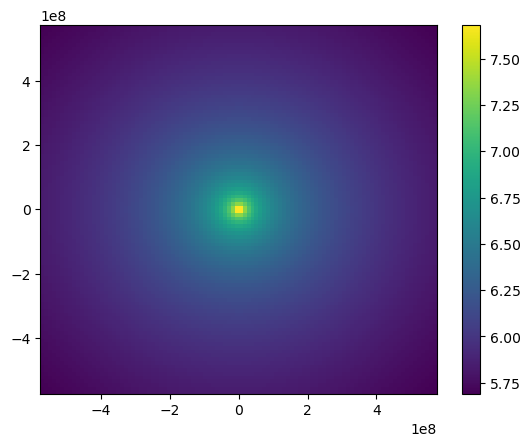

In [5]:
x = np.linspace(-1.5*d_to_moon, 1.5*d_to_moon, 100)
y = np.linspace(-1.5*d_to_moon, 1.5*d_to_moon, 100)
X, Y = np.meshgrid(x,y)
Z = V(M_earth, 0.0, 0.0, X, Y)

fig, ax = plt.subplots()
colormesh = ax.pcolormesh(X,Y,np.log10(-Z),cmap="viridis")
fig.colorbar(colormesh)

## Part 2: The Gravitational Potential of the Earth-Moon System
-----

Now, imagine the Earth is at the origin $(x_{E},y_{E}) = (0,0)$, 
and the moon is at a location $(x_{M},y_{M}) = \big( \frac{d_{EM}}{\sqrt{2}}, \frac{d_{EM}}{\sqrt{2}} \big)$.

1. Make an updated 2D color-mesh plot, from $-1.5d_{EM}$ to $+1.5d_{EM}$,
of the gravitational potential of the combined Earth-Moon system.

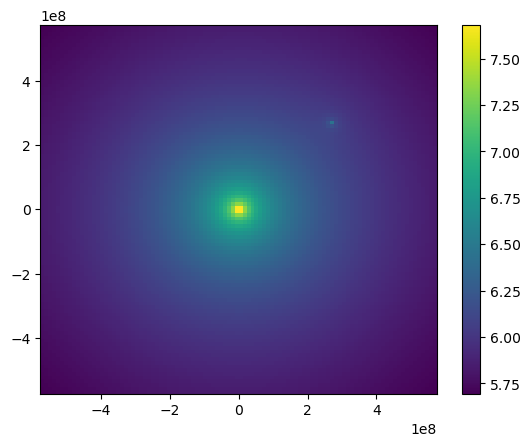

In [6]:
x = np.linspace(-1.5*d_to_moon, 1.5*d_to_moon, 100)
y = np.linspace(-1.5*d_to_moon, 1.5*d_to_moon, 100)
X, Y = np.meshgrid(x,y)
Z = V(M_earth, 0.0, 0.0, X, Y) + V(M_moon, d_to_moon/(np.sqrt(2)), d_to_moon/(np.sqrt(2)), X, Y)
fig, ax = plt.subplots()
colormesh = ax.pcolormesh(X,Y,np.log10(-Z),cmap="viridis")
fig.colorbar(colormesh)

2. Additionally, make a 2D contour plot over the same $x$ and $y$ range.
Do not let all the contours bunch up around the Earth and Moon.
You will probably again need to tell matplotlib to use a logarithmic color scale.

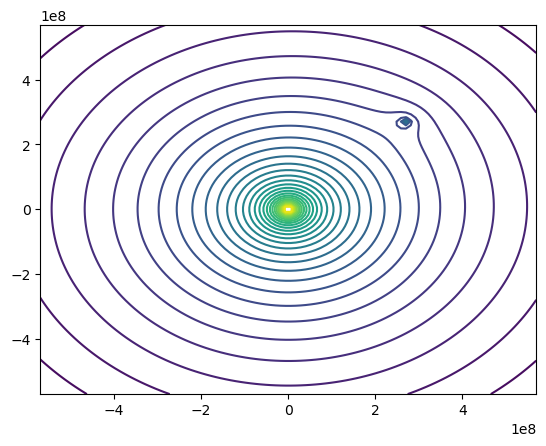

In [7]:
x = np.linspace(-1.5*d_to_moon, 1.5*d_to_moon, 100)
y = np.linspace(-1.5*d_to_moon, 1.5*d_to_moon, 100)
X, Y = np.meshgrid(x,y)
Z = V(M_earth, 0.0, 0.0, X, Y) + V(M_moon, d_to_moon/(np.sqrt(2)), d_to_moon/(np.sqrt(2)), X, Y)
fig, ax = plt.subplots()
#levels = np.linspace(np.min(Z), np.max(Z), 30)
ax.contour(X, Y, np.log(-Z), levels=30)

## Part 3: The Gravitational Force Field of the Earth-Moon System
----
The gravitational force $\vec{F}$ 
that a mass $M_1$ exerts on a mass $m_2$ is:

$$\vec{F}_{21} = -G \frac{M_1 m_2}{|\vec{r}_{21}|^2} \hat{r}_{21}$$

where $\vec{r}_{21}$ is the displacement vector from $M_1$ to $m_2$.

1. Code up a function that takes as an input the mass of a body $M_1$, 
the mass of a secondary body $m_2$,
the cartesian location of the first mass $(x_1, y_1)$, 
and the cartesian location of the second body $(x_2, y_2)$. 
Have the function return the two gravitational force components, 
$F_x$ and $F_y$, experienced by the mass $m_2$ 
from the force exerted by $M_1$.
Note that the gravitational force contains a singularity, 
and so if you made the approximation that the Earth is a finite point,
you will need to avoid it.
Like for the 1D potential, make sure it follows modern best-coding practices.

In [8]:
def F_grav(M1, m2, x1, y1, x2, y2):
    """
    Calculates the gravitational force exerted on m2 by M1. 
    Inputs: positive float M1, positive float m2, np.ndarray pos1, np.ndarray pos2
    Returns: float vecF[0], float vecF[1]
    """
    if not (isinstance(M1,float) and isinstance(m2,float) and (isinstance(x1,float) or isinstance(x1, np.ndarray)) and (isinstance(y1,float) or isinstance(y1, np.ndarray)) and (isinstance(x2,float) or isinstance(x2, np.ndarray)) and (isinstance(y2,float) or isinstance(y2, np.ndarray))):
        raise TypeError
    if M1<0 or m2<0:
        raise ValueError("Masses must be positive")
    r = np.sqrt((x2-x1)**2+(y2-y1)**2)
    r = np.where(np.isclose(r,0), np.nan, r)
    #if not isinstance(vecF[0],np.float64) and isinstance(vecF[1],np.float64):
        #raise TypeError("Returns are not floats")
    return -G*M1*m2*(x2-x1)/r**3, -G*M1*m2*(y2-y1)/r**3

2. Assuming the Earth is still at the origin and the Moon is still at 
$(x_M, y_M) = \big( \frac{d_{EM}}{\sqrt{2}}, \frac{d_{EM}}{\sqrt{2}} \big)$, 
make a 2D streamplot of the gravitational force the Earth-Moon system 
will exert on the Apollo 11 command module.
Plot the force over the same x-y range of $-1.5 d_{EM}$ to $+1.5 d_{EM}$.
Add a nice color bar, which will again probably need to be logarithmic.
Mark the location of the earth with a black circle, and the moon with a black square.
Add a legend.

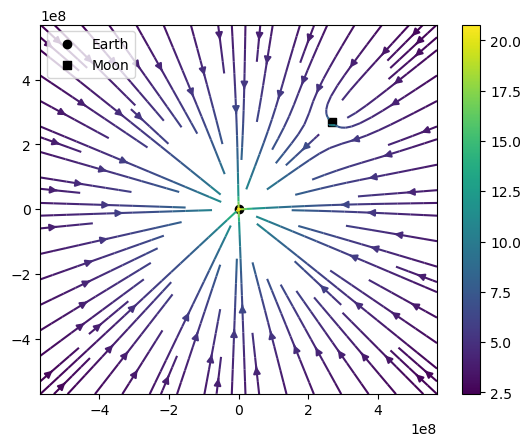

In [9]:
x = np.linspace(-1.5*d_to_moon, 1.5*d_to_moon, 100)
y = np.linspace(-1.5*d_to_moon, 1.5*d_to_moon, 100)
X, Y = np.meshgrid(x,y)
F_xearth, F_yearth = F_grav(M_earth, apollo_command_mass, 0.0, 0.0, X,Y)
F_xmoon, F_ymoon = F_grav(M_moon, apollo_command_mass, d_to_moon/np.sqrt(2), d_to_moon/np.sqrt(2), X,Y)
F_x = F_xearth + F_xmoon
F_y = F_yearth + F_ymoon
fig, ax = plt.subplots()
v = np.log(F_x**2+F_y**2)
stream = ax.streamplot(X, Y, F_x, F_y, color=v, cmap='viridis')
ax.scatter(0.0,0.0,marker="o", color="black", label="Earth")
ax.scatter(d_to_moon/np.sqrt(2),d_to_moon/np.sqrt(2),marker="s", color="black", label="Moon")
fig.colorbar(stream.lines, ax=ax)
plt.legend(loc='upper left')

3. You will note there is a point between the Earth and the Moon where the field lines seem to vanish. This is the point where the Earth's and Moon's gravitational forces cancel eachother. By setting $|\vec{F}_{moon}| = |\vec{F}_{earth}|$, calculate the radial distance of the "balance point." From there, identify the $x$ and $y$ coordinates of the balance point. Typeset your derivation (show multiple steps!) in latex in a markdown cell below. Then, calculate it numerically, and draw the answer onto a new version of your force field plot. Again mark the location of the earth with a black circle, and the moon with a black square; mark the location of the balance point with a red x. Add a legend.

**Your Derivation Goes in the markdown cell below:**

In radial coordinates where $r$ is the distance from the Earth, when we are in line with the Moon and Earth and their pulls are equal, we have $\frac{GM_{earth}}{r^2}=\frac{GM_{moon}}{(r-1)^2}$, using units where the distance from the Earth to the Moon is 1. 
Multiplying both sides by $r^2(r-d)^2$, distributing, and moving to one side, we have the quadratic $(M_{earth}-M_{moon})r^2-2M_{earth}r+1=0$. This is solved for the distance by $r=\frac{M_{earth}-\sqrt{M_{moon}M_{earth}}}{M_{earth}-M_{moon}}\approx0.90$. This means that the stationary point is about 90\% of the way to the Moon. This corresponds to x and y coordinates that are both $0.9*d_{to\space moon}/\sqrt 2=0.6364d_{to\space moon}$. 

And your updated plot, including the balance point, goes in the cell below.

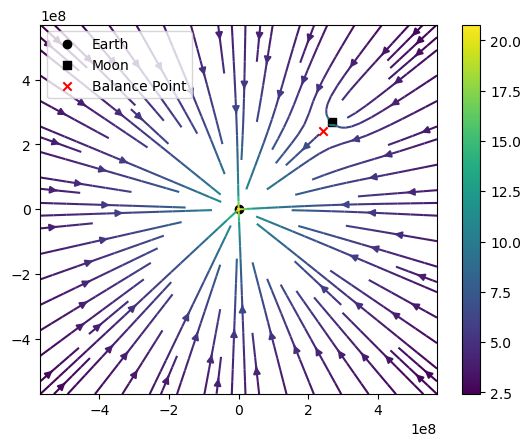

In [10]:
x = np.linspace(-1.5*d_to_moon, 1.5*d_to_moon, 100)
y = np.linspace(-1.5*d_to_moon, 1.5*d_to_moon, 100)
X, Y = np.meshgrid(x,y)
F_xearth, F_yearth = F_grav(M_earth, apollo_command_mass, 0.0, 0.0, X,Y)
F_xmoon, F_ymoon = F_grav(M_moon, apollo_command_mass, d_to_moon/np.sqrt(2), d_to_moon/np.sqrt(2), X,Y)
F_x = F_xearth + F_xmoon
F_y = F_yearth + F_ymoon
fig, ax = plt.subplots()
v = np.log(F_x**2+F_y**2)
stream = ax.streamplot(X, Y, F_x, F_y, color=v, cmap='viridis')
ax.scatter(0.0,0.0,marker="o", color="black", label="Earth")
ax.scatter(d_to_moon/np.sqrt(2),d_to_moon/np.sqrt(2),marker="s", color="black", label="Moon")
ax.scatter(0.6364*d_to_moon, 0.6364*d_to_moon, marker="x", color="red", label="Balance Point")
fig.colorbar(stream.lines, ax=ax)
plt.legend(loc='upper left')

4. Quantitatively discuss your conclusions. Is the balance point close to the Moon or Earth? How close? Does this make sense?

**Your Answer Goes in the markdown cell below:**

It's very close to the Moon. This makes sense because the Moon's gravity is much weaker than that of the Earth, and gravity drops off quickly with distance, so the point where their gravity is equal must be closer to the small mass. 

## Part 4: Altitude of the Saturn V Rocket
----
Rockets function by conservation of momentum.
The ejection of fuel backwards propels the rocket forwards.
The change in a rocket's velocity $\Delta v$ as a 
function of time $t$ (under a set of simplifying assumptions) 
is given by the Tsiolkovsky rocket equation:

$$\Delta v(t) = v_e \ln \left(\frac{m_0}{m(t)}\right) - gt$$

where $m_0$ is the initial "wet" mass (fuel + rocket parts + payload), 
$m(t) = m_0 - \dot{m}t$ is the mass at time $t$, 
$\dot{m}$ is the fuel burn rate (which we will assume to be constant), 
$v_e$ is the fuel exhaust velocity, and $g$ is the gravitational acceleration.

You can find the altitude $h$ of the rocket at "burnout" 
(when all the fuel is used up) by integrating the velocity over time:

$$h = \int_{0}^{T} \Delta v(t) \, dt$$

where $T$ is the total burn time of the rocket, 
which by conservation of momentum arguments is:

$$T = \frac{m_0 - m_f}{\dot{m}}$$

where $m_f$ is the final "dry mass" of the rocket, 
once all the fuel is burned.

1. Calculate the burn time $T$ for the first stage of
the new Saturn V rocket that NASA is planning
to use to carry the Apollo capsule.

In [11]:
T = (m0 - mf) / mdot

2. Define a function that returns the change in velocity $\Delta v(t)$.
It should take all necessary arguments, meaning: the time, 
wet mass, dry mass, burn rate, exhaust speed, and gravitational constant $g$. 
Have it return the change in velocity.
Note that the rocket eventually runs out of fuel, 
so you should design your function carefully so that 
$\Delta v$ eventually becomes zero after all fuel is spent.
Again, document and guard your function according to best practices.

In [12]:
def delta_v(t, m0=m0, mf=mf, mdot=mdot, ve=ve):
    """
    Calculates the change in velocity at a time t, with wet mass m0, dry mass mf, burn rate mdot, and exhaust velocity ve.
    Inputs: all must be floats >0 or ndarrays
    Return: must be float or ndarray
    """
    inputs = [t, m0, mf, mdot, ve]
    for i in inputs:
        if not (isinstance(i, float) or isinstance(i, np.ndarray)): #prevents inputs that are not floats or ndarrays
            raise TypeError
        if isinstance(i, float) and i<=0:  #prevents negative and zero inputs
            raise ValueError
    m = np.where(t<np.full_like(t, T), m0 - mdot*t, mf)
    return np.where(t<np.full_like(t, T), ve*np.log(m0/m) - g*t, 0)


3. Compute the altitude of the rocket at the end of the burn.
Do this by numerically integrating from $t=0$ (launch) to $t=T$ (burnout).
Use the `scipy.integrate.quad()` function.

In [13]:
result, error = quad(delta_v, 0, T)
print(f"T: {T}")
print(f"h: {result}")

T: 157.69230769230768
h: 74093.98013366401


4. Just last week, NASA got the test results back from the first prototype
of Saturn V. They found that it burned for about 160 seconds
and lifted the system to an altitude of about 70km.
Director Kranz has asked you to compare your calculations for 
$T$ and $h$ to the testing data.
You should offer some explanations about why your calculation
is an over or under estimate, e.g. neglecting drag.

**Your Answer Goes in the markdown cell below:**

Our value for $T$ is lower than expected, but only by a tiny margin. Perhaps in real life, the fuel did not burn completely, leaving some wet mass present when the burners were shut off.
Our value for $h$ is slightly too large, which makes perfect sense given that we ignored drag-- since our system doesn't have the air trying to slow it down, it goes higher on the same acceleration. 